<a href="https://www.kaggle.com/code/daniilkrizhanovskyi/motion-s-text-to-sign-motion-generation?scriptVersionId=312877487" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Motion-S v6: Retrieval-Initialized Refinement

**Core idea:** Instead of generating tokens from scratch (hard),
give the model retrieved tokens as INPUT and train it to REFINE them (easy).

```
Input:  text_embedding + retrieved_token_embeddings + position
Output: refined tokens (closer to ground truth)
```

This is much easier to learn because retrieved tokens are already ~85% similar.
Also includes **pure retrieval voting** baseline for comparison.

---

## 0. Setup

In [1]:
import os, gc, json, math, random, warnings, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

T_START = time.time()
TIME_LIMIT = 8.5 * 3600
def time_left(): return TIME_LIMIT - (time.time() - T_START)
def time_ok(margin=600): return time_left() > margin
print('Setup OK')

Setup OK


In [2]:
def test_cuda():
    if not torch.cuda.is_available(): return False
    try:
        x = torch.randn(2,2,device='cuda')
        _ = F.gelu(x).cpu(); return True
    except: return False

DEVICE = torch.device('cuda' if torch.cuda.is_available() and test_cuda() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'Mem: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
Mem: 15.6 GB


In [3]:
import glob
INPUT_DIR = None
for d in sorted(Path('/kaggle/input').iterdir()):
    if (d / 'train.csv').exists(): INPUT_DIR = d; break
if INPUT_DIR is None:
    hits = glob.glob('/kaggle/input/**/train.csv', recursive=True)
    if hits: INPUT_DIR = Path(hits[0]).parent
assert INPUT_DIR is not None
print(f'Data: {INPUT_DIR}')

OUTPUT_DIR = Path('/kaggle/working')
TRAIN_CSV = INPUT_DIR / 'train.csv'
TEST_CSV  = INPUT_DIR / 'test.csv'

TOKEN_COLS = ['base_tokens','residual_1','residual_2',
              'residual_3','residual_4','residual_5']

class CFG:
    num_codebook = 512
    num_layers   = 6
    max_seq_len  = 800
    min_seq_len  = 40
    text_dim     = 512
    # Refiner model
    d_model      = 512
    nhead        = 8
    n_layers     = 8
    dim_ff       = 2048
    dropout      = 0.1
    # Training
    batch_size   = 48
    accum_steps  = 2
    lr           = 2e-4
    weight_decay = 0.01
    epochs       = 30
    warmup_ratio = 0.08
    grad_clip    = 1.0
    label_smooth = 0.1
    # Retrieval
    ret_k        = 20
    ret_k_train  = 5   # for training: use neighbors 2-6 (skip self=top1)
    # Inference
    temperatures = [0.6, 0.7, 0.8]
    top_k        = 48
    n_cand_per_t = 2
print('CFG OK')

Data: /kaggle/input/competitions/motion-s-hierarchical-text-to-motion-generation-for-sign-language
CFG OK


## 1. Data

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

def parse_tokens(s):
    if pd.isna(s) or str(s).strip() == '': return []
    return list(map(int, str(s).strip().split()))

train_df['seq_len'] = train_df['base_tokens'].apply(lambda x: len(parse_tokens(x)))
train_valid = train_df[
    (train_df['seq_len'] >= CFG.min_seq_len) &
    (train_df['seq_len'] <= CFG.max_seq_len)
].copy().reset_index(drop=True)
print(f'Train valid: {len(train_valid)}, Test: {len(test_df)}')

train_tokens = []
for i in range(len(train_valid)):
    row = train_valid.iloc[i]
    layers = [parse_tokens(row[c]) for c in TOKEN_COLS]
    sl = len(layers[0])
    train_tokens.append(np.array([l[:sl] for l in layers], dtype=np.int64))
print(f'Parsed {len(train_tokens)} token arrays')
print(f'Time: {time.time()-T_START:.0f}s')

Train valid: 12373, Test: 3000
Parsed 12373 token arrays
Time: 102s


## 2. CLIP Encoding

In [5]:
try:
    from transformers import CLIPTokenizer, CLIPTextModel
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,'-m','pip','install','-q','transformers'])
    from transformers import CLIPTokenizer, CLIPTextModel

clip_path = 'openai/clip-vit-base-patch32'
clip_tok = CLIPTokenizer.from_pretrained(clip_path)
clip_mdl = CLIPTextModel.from_pretrained(clip_path).cpu().eval()
for p in clip_mdl.parameters(): p.requires_grad = False
print(f'CLIP: {sum(p.numel() for p in clip_mdl.parameters())/1e6:.0f}M')

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.post_layernorm.bias                               | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

CLIP: 63M


In [6]:
@torch.no_grad()
def clip_encode(texts, bs=128):
    out = []
    for i in range(0,len(texts),bs):
        inp = clip_tok(texts[i:i+bs], padding='max_length',
                       truncation=True, max_length=77, return_tensors='pt')
        o = clip_mdl(**inp)
        out.append(F.normalize(o.pooler_output, dim=-1))
    return torch.cat(out,0)

print('Encoding...')
t0 = time.time()

tr_texts = [str(r['sentence']).strip()+' [SEP] '+str(r['gloss']).strip()
            for _,r in train_valid.iterrows()]
te_texts = [str(r['sentence']).strip()+' [SEP] '+str(r['gloss']).strip()
            for _,r in test_df.iterrows()]
tr_emb = clip_encode(tr_texts)
te_emb = clip_encode(te_texts)
print(f'  combined: {tr_emb.shape} ({time.time()-t0:.0f}s)')

tr_ge = clip_encode(train_valid['gloss'].tolist())
te_ge = clip_encode(test_df['gloss'].tolist())
tr_se = clip_encode(train_valid['sentence'].tolist())
te_se = clip_encode(test_df['sentence'].tolist())
print(f'  gloss+sentence ({time.time()-t0:.0f}s)')

del clip_mdl, clip_tok; gc.collect()
print(f'CLIP done: {time.time()-t0:.0f}s')

Encoding...
  combined: torch.Size([12373, 512]) (709s)
  gloss+sentence (2027s)
CLIP done: 2027s


## 3. Retrieval (train-to-train + test-to-train)

In [7]:
def build_retrieval(te_ge, te_se, te_emb, tr_ge, tr_se, tr_emb, K, ch=500,
                     exclude_self=False):
    """3-way retrieval: 0.4*gloss + 0.3*sentence + 0.3*combined."""
    N = te_ge.shape[0]
    idxs = np.zeros((N, K), dtype=np.int64)
    sims = np.zeros((N, K), dtype=np.float32)
    for i in range(0, N, ch):
        e = min(i+ch, N)
        sg = cosine_similarity(te_ge[i:e].numpy(), tr_ge.numpy())
        ss = cosine_similarity(te_se[i:e].numpy(), tr_se.numpy())
        sc = cosine_similarity(te_emb[i:e].numpy(), tr_emb.numpy())
        combined = 0.4 * sg + 0.3 * ss + 0.3 * sc
        if exclude_self:
            for j in range(e-i):
                combined[j, i+j] = -1.0  # exclude self
        for j in range(e-i):
            ix = np.argpartition(combined[j], -K)[-K:]
            ix = ix[np.argsort(combined[j][ix])[::-1]]
            idxs[i+j] = ix
            sims[i+j] = combined[j][ix]
    return idxs, sims

# Test-to-train retrieval
print('Test retrieval...')
t0 = time.time()
te_ret_idx, te_ret_sim = build_retrieval(
    te_ge, te_se, te_emb, tr_ge, tr_se, tr_emb, K=CFG.ret_k)
print(f'  Test top-1: mean={te_ret_sim[:,0].mean():.4f} ({time.time()-t0:.0f}s)')

# Train-to-train retrieval (leave-one-out for training the refiner)
print('Train retrieval (leave-one-out)...')
t0 = time.time()
tr_ret_idx, tr_ret_sim = build_retrieval(
    tr_ge, tr_se, tr_emb, tr_ge, tr_se, tr_emb,
    K=CFG.ret_k_train+1, exclude_self=True)
# Skip idx 0 (which could still be very similar), use idx 0..ret_k_train-1
print(f'  Train top-1 (loo): mean={tr_ret_sim[:,0].mean():.4f} ({time.time()-t0:.0f}s)')

del tr_se, te_se, tr_ge, te_ge; gc.collect()
print(f'Time: {time.time()-T_START:.0f}s')

Test retrieval...
  Test top-1: mean=0.8450 (1s)
Train retrieval (leave-one-out)...
  Train top-1 (loo): mean=0.8438 (6s)
Time: 2163s


## 4. Retrieval Token Interpolation

For each sample, get retrieved tokens aligned to target length.

In [8]:
def get_retrieved_tokens(ret_idx_row, ret_sim_row, target_len, k=5):
    """Get position-aligned tokens from top-K neighbors.
    Returns [6, target_len] numpy array of weighted-voted tokens."""
    # Soft votes per position per layer
    votes = np.zeros((6, target_len, CFG.num_codebook), dtype=np.float32)
    w = np.exp(ret_sim_row[:k] * 5.0)
    w = w / w.sum()
    
    for ki in range(k):
        tr_i = ret_idx_row[ki]
        tok = train_tokens[tr_i]  # [6, sl_src]
        src_len = tok.shape[1]
        if src_len == 0: continue
        for t in range(target_len):
            sp = min(int(t * src_len / target_len), src_len - 1)
            for li in range(6):
                votes[li, t, tok[li, sp]] += w[ki]
    
    # Pick argmax (deterministic, most common token)
    result = np.argmax(votes, axis=-1)  # [6, target_len]
    return result.astype(np.int64)


def get_top1_tokens(ret_idx_row, target_len):
    """Simple: copy top-1 neighbor tokens, resize to target_len."""
    tok = train_tokens[ret_idx_row[0]]  # [6, sl_src]
    src_len = tok.shape[1]
    if src_len == 0:
        return np.zeros((6, target_len), dtype=np.int64)
    result = np.zeros((6, target_len), dtype=np.int64)
    for t in range(target_len):
        sp = min(int(t * src_len / target_len), src_len - 1)
        result[:, t] = tok[:, sp]
    return result


# Test
rt = get_retrieved_tokens(te_ret_idx[0], te_ret_sim[0], 100, k=5)
print(f'Retrieved tokens: {rt.shape}, range=[{rt.min()},{rt.max()}]')
print(f'Time: {time.time()-T_START:.0f}s')

Retrieved tokens: (6, 100), range=[3,506]
Time: 2163s


## 5. Length Prediction (retrieval-based)

In [9]:
def pred_len_retrieval(ret_idx_row, ret_sim_row, k=5):
    """Weighted average of top-K neighbor lengths."""
    w = np.exp(ret_sim_row[:k] * 5.0); w = w / w.sum()
    lengths = np.array([train_tokens[ret_idx_row[ki]].shape[1] for ki in range(k)])
    pred = int(np.round(np.dot(w, lengths)))
    return max(CFG.min_seq_len, min(CFG.max_seq_len, pred))

# Also train a simple MLP for blending
class LenPred(nn.Module):
    def __init__(self, d=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,256), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256,128), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(128,1))
    def forward(self, x): return self.net(x).squeeze(-1)

lm = LenPred().to(DEVICE)
lo = torch.optim.AdamW(lm.parameters(), lr=1e-3)
Xl = tr_emb.clone()
yl = torch.log(torch.tensor(train_valid['seq_len'].values, dtype=torch.float32))
ld = DataLoader(torch.utils.data.TensorDataset(Xl, yl), batch_size=512, shuffle=True)
lm.train()
for ep in range(100):
    for xb, yb in ld:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = F.mse_loss(lm(xb), yb)
        lo.zero_grad(); loss.backward(); lo.step()
lm.eval()

@torch.no_grad()
def pred_len_hybrid(test_idx, emb, ret_idx_row, ret_sim_row, alpha=0.3):
    if emb.dim() == 1: emb = emb.unsqueeze(0)
    ml = torch.exp(lm(emb.to(DEVICE))).round().long().clamp(
        CFG.min_seq_len, CFG.max_seq_len).item()
    rl = pred_len_retrieval(ret_idx_row, ret_sim_row)
    h = int(np.round(alpha * ml + (1 - alpha) * rl))
    return max(CFG.min_seq_len, min(CFG.max_seq_len, h))

for i in range(3):
    rl = pred_len_retrieval(te_ret_idx[i], te_ret_sim[i])
    hl = pred_len_hybrid(i, te_emb[i], te_ret_idx[i], te_ret_sim[i])
    print(f'  Test {i}: ret={rl}, hybrid={hl}')
print(f'Time: {time.time()-T_START:.0f}s')

  Test 0: ret=88, hybrid=96
  Test 1: ret=133, hybrid=122
  Test 2: ret=114, hybrid=105
Time: 2177s


## 6. Refinement Model

Input: positional encoding + text embedding + **retrieved token embeddings**
Output: refined token logits for all 6 layers

The model learns the residual: retrieved_tokens → ground_truth tokens.

In [10]:
class PosEnc(nn.Module):
    def __init__(self, d, mx=1024):
        super().__init__()
        pe = torch.zeros(mx, d)
        pos = torch.arange(mx).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.)/d))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, T): return self.pe[:,:T,:]


class RefinerModel(nn.Module):
    """Takes retrieved tokens + text → refined tokens for all 6 layers.
    The key insight: retrieved tokens provide position-specific signal.
    Model only needs to learn corrections."""
    def __init__(self, cfg):
        super().__init__()
        d = cfg.d_model; self.cfg = cfg
        # Shared codebook embedding + per-layer learned scale
        self.ret_tok_emb = nn.Embedding(cfg.num_codebook, d)
        self.layer_emb = nn.Embedding(6, d)  # which RVQ layer
        # Text projection
        self.txt_proj = nn.Sequential(
            nn.Linear(cfg.text_dim, d), nn.GELU(),
            nn.LayerNorm(d), nn.Linear(d, d))
        self.pos_enc = PosEnc(d, mx=cfg.max_seq_len+1)
        self.len_emb = nn.Embedding(cfg.max_seq_len+1, d)
        # Transformer
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d, nhead=cfg.nhead, dim_feedforward=cfg.dim_ff,
            dropout=cfg.dropout, activation='gelu',
            batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=cfg.n_layers)
        # Output heads for all 6 layers
        self.heads = nn.ModuleList([
            nn.Sequential(nn.LayerNorm(d), nn.Linear(d, cfg.num_codebook))
            for _ in range(6)])

    def forward(self, txt_emb, ret_tokens, sls, tmask=None):
        """
        txt_emb: [B, 512] pooled CLIP
        ret_tokens: [B, 6, T] retrieved token indices
        sls: [B] sequence lengths
        tmask: [B, T] valid positions
        Returns: [B, 6, T, 512] logits
        """
        B, _, T = ret_tokens.shape
        # Embed retrieved tokens: sum embeddings from all 6 layers
        layer_ids = torch.arange(6, device=ret_tokens.device)
        ret_feat = torch.zeros(B, T, self.cfg.d_model, device=ret_tokens.device)
        for li in range(6):
            ret_feat = ret_feat + self.ret_tok_emb(ret_tokens[:, li, :]) + self.layer_emb(layer_ids[li])
        ret_feat = ret_feat / 6.0  # average
        # Build input
        pos = self.pos_enc(T).expand(B,-1,-1)
        txt = self.txt_proj(txt_emb).unsqueeze(1)
        lc = self.len_emb(sls.clamp(0,self.cfg.max_seq_len)).unsqueeze(1)
        x = pos + txt + lc + ret_feat  # position + text + length + retrieved
        kpm = ~tmask if tmask is not None else None
        out = self.encoder(x, src_key_padding_mask=kpm)
        return torch.stack([h(out) for h in self.heads], 1)  # [B, 6, T, 512]


model = RefinerModel(CFG).to(DEVICE)
nparams = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'RefinerModel: {nparams/1e6:.2f}M params')
print(f'Time: {time.time()-T_START:.0f}s')

RefinerModel: 28.00M params
Time: 2177s


## 7. Training Dataset

For each training sample, use leave-one-out retrieved tokens as input.

In [11]:
class RefineDS(Dataset):
    """Training: use leave-one-out retrieved tokens as input,
    ground truth tokens as target."""
    def __init__(self, embs, tokens_list, ret_idx, ret_sim, ret_k):
        self.embs = embs
        self.tokens = tokens_list
        self.sls = [t.shape[1] for t in tokens_list]
        self.ret_idx = ret_idx
        self.ret_sim = ret_sim
        self.ret_k = ret_k
    
    def __len__(self): return len(self.tokens)
    
    def __getitem__(self, i):
        sl = self.sls[i]
        # Get retrieved tokens aligned to this sample's length
        # Randomly pick which neighbor rank to use (1-5) for diversity
        k_start = random.randint(0, max(0, self.ret_k - 3))
        ret_tok = get_retrieved_tokens(
            self.ret_idx[i, k_start:k_start+3],
            self.ret_sim[i, k_start:k_start+3],
            sl, k=3)
        return dict(emb=self.embs[i], tok=self.tokens[i],
                    ret_tok=ret_tok, sl=sl)

def collate(batch):
    B = len(batch); ms = max(b['sl'] for b in batch)
    emb = torch.stack([b['emb'] for b in batch])
    tok = torch.zeros(B,6,ms, dtype=torch.long)
    ret_tok = torch.zeros(B,6,ms, dtype=torch.long)
    tmask = torch.zeros(B,ms, dtype=torch.bool)
    sls = torch.tensor([b['sl'] for b in batch], dtype=torch.long)
    for i,b in enumerate(batch):
        sl = b['sl']
        tok[i,:,:sl] = torch.tensor(b['tok'][:,:sl])
        ret_tok[i,:,:sl] = torch.tensor(b['ret_tok'][:,:sl])
        tmask[i,:sl] = True
    return dict(emb=emb, tok=tok, ret_tok=ret_tok, tmask=tmask, sls=sls)

ds = RefineDS(tr_emb, train_tokens, tr_ret_idx, tr_ret_sim, CFG.ret_k_train)
dl = DataLoader(ds, batch_size=CFG.batch_size, shuffle=True,
                collate_fn=collate, num_workers=2, pin_memory=True, drop_last=True)
print(f'{len(ds)} samples, {len(dl)} batches')

12373 samples, 257 batches


In [12]:
print('=== Training Refiner ===')

opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr,
                        weight_decay=CFG.weight_decay, betas=(0.9,0.98))
total_steps = CFG.epochs * len(dl) // CFG.accum_steps
wu = int(total_steps * CFG.warmup_ratio)
def lr_fn(s):
    if s < wu: return s/max(1,wu)
    return 0.5*(1+math.cos(math.pi*(s-wu)/max(1,total_steps-wu)))
sch = torch.optim.lr_scheduler.LambdaLR(opt, lr_fn)
scaler = GradScaler()

best_loss = float('inf'); hist = []; model.train(); gs = 0
t_train = time.time()

for ep in range(CFG.epochs):
    if not time_ok(margin=1800):  # 30 min for inference
        print(f'Time guard: stop ep {ep} ({time_left()/60:.0f}min left)')
        break
    el, et = 0., 0
    opt.zero_grad()
    for bi, batch in enumerate(dl):
        emb = batch['emb'].to(DEVICE)
        tok = batch['tok'].to(DEVICE)       # [B,6,T] targets
        ret_tok = batch['ret_tok'].to(DEVICE)  # [B,6,T] retrieved
        tmask = batch['tmask'].to(DEVICE)
        sls = batch['sls'].to(DEVICE)
        
        with autocast():
            logits = model(emb, ret_tok, sls, tmask)  # [B,6,T,512]
            B, NL, T, V = logits.shape
            lf = F.cross_entropy(logits.reshape(-1,V), tok.reshape(-1),
                                 label_smoothing=CFG.label_smooth, reduction='none')
            mf = tmask.unsqueeze(1).expand(-1,NL,-1).reshape(-1).float()
            loss = (lf * mf).sum() / mf.sum() / CFG.accum_steps
        scaler.scale(loss).backward()
        
        if (bi + 1) % CFG.accum_steps == 0:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            scaler.step(opt); scaler.update(); sch.step()
            opt.zero_grad(); gs += 1
        
        nt = mf.sum().item()
        el += loss.item() * CFG.accum_steps * nt; et += nt
        if gs > 0 and gs % 100 == 0 and (bi+1) % CFG.accum_steps == 0:
            print(f'  s{gs}: loss={el/et:.4f} lr={sch.get_last_lr()[0]:.2e}')
    al = el/max(1,et); hist.append(al)
    ep_t = (time.time()-t_train)/(ep+1)
    print(f'Ep {ep+1}/{CFG.epochs}: {al:.4f} ({ep_t:.0f}s/ep, {time_left()/60:.0f}min left)')
    if al < best_loss:
        best_loss = al; torch.save(model.state_dict(), OUTPUT_DIR/'refiner_best.pth')
print(f'Best: {best_loss:.4f}, time: {time.time()-t_train:.0f}s')

=== Training Refiner ===
  s100: loss=5.9271 lr=6.49e-05
Ep 1/30: 5.8340 (79s/ep, 472min left)
  s200: loss=5.4651 lr=1.30e-04
Ep 2/30: 5.3912 (78s/ep, 471min left)
  s300: loss=5.1991 lr=1.95e-04
Ep 3/30: 5.1465 (78s/ep, 470min left)
  s400: loss=5.0581 lr=2.00e-04
  s500: loss=5.0150 lr=1.99e-04
Ep 4/30: 5.0108 (77s/ep, 469min left)
  s600: loss=4.9274 lr=1.97e-04
Ep 5/30: 4.9211 (77s/ep, 467min left)
  s700: loss=4.8572 lr=1.94e-04
Ep 6/30: 4.8503 (77s/ep, 466min left)
  s800: loss=4.7885 lr=1.91e-04
Ep 7/30: 4.7896 (77s/ep, 465min left)
  s900: loss=4.7168 lr=1.87e-04
  s1000: loss=4.7361 lr=1.82e-04
Ep 8/30: 4.7359 (77s/ep, 463min left)
  s1100: loss=4.6853 lr=1.76e-04
Ep 9/30: 4.6870 (77s/ep, 462min left)
  s1200: loss=4.6284 lr=1.70e-04
Ep 10/30: 4.6384 (77s/ep, 461min left)
  s1300: loss=4.5809 lr=1.64e-04
  s1400: loss=4.5934 lr=1.57e-04
Ep 11/30: 4.5915 (77s/ep, 460min left)
  s1500: loss=4.5492 lr=1.49e-04
Ep 12/30: 4.5452 (77s/ep, 458min left)
  s1600: loss=4.4918 lr=1.41e-

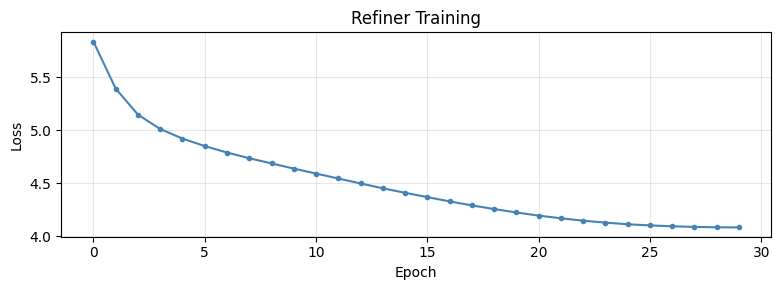

In [13]:
plt.figure(figsize=(8,3))
plt.plot(hist,'o-',color='steelblue',ms=3)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Refiner Training')
plt.grid(True,alpha=0.3); plt.tight_layout(); plt.show()

## 8. Inference

In [14]:
model.load_state_dict(torch.load(OUTPUT_DIR/'refiner_best.pth', map_location=DEVICE))
model.eval()
print('Refiner loaded')

Refiner loaded


In [15]:
@torch.no_grad()
def generate_batch_v6(start_idx, end_idx):
    B = end_idx - start_idx
    
    # Predict lengths
    seq_lens = []
    for i in range(start_idx, end_idx):
        sl = pred_len_hybrid(i, te_emb[i], te_ret_idx[i], te_ret_sim[i])
        seq_lens.append(sl)
    seq_lens_t = torch.tensor(seq_lens, device=DEVICE, dtype=torch.long)
    max_sl = max(seq_lens)
    mask = torch.arange(max_sl, device=DEVICE).unsqueeze(0) < seq_lens_t.unsqueeze(1)
    embs = te_emb[start_idx:end_idx].to(DEVICE)
    
    # Build retrieved tokens for the batch
    ret_tokens_np = np.zeros((B, 6, max_sl), dtype=np.int64)
    for i in range(B):
        ti = start_idx + i
        sl = seq_lens[i]
        rt = get_retrieved_tokens(te_ret_idx[ti], te_ret_sim[ti], sl, k=10)
        ret_tokens_np[i, :, :sl] = rt
    ret_tokens = torch.tensor(ret_tokens_np, device=DEVICE, dtype=torch.long)
    
    # Model forward
    logits = model(embs, ret_tokens, seq_lens_t, mask)  # [B,6,max_sl,512]
    
    # Temperature sweep + multi-candidate sampling
    results = []
    for i in range(B):
        sl = seq_lens[i]
        best_tok = None; best_ll = float('-inf')
        
        for temp in CFG.temperatures:
            lg = logits[i, :, :sl, :] / temp  # [6, sl, 512]
            if CFG.top_k > 0:
                kv, _ = torch.topk(lg, CFG.top_k, dim=-1)
                lg[lg < kv[..., -1:]] = float('-inf')
            probs = F.softmax(lg, -1)  # [6, sl, 512]
            flat = probs.reshape(-1, CFG.num_codebook)
            
            for _ in range(CFG.n_cand_per_t):
                sampled = torch.multinomial(flat, 1).reshape(6, sl)
                # Log-likelihood
                ll = 0.0
                for li in range(6):
                    ll += torch.log(probs[li, torch.arange(sl, device=DEVICE),
                                          sampled[li]] + 1e-10).sum().item()
                if ll > best_ll:
                    best_ll = ll; best_tok = sampled
        
        results.append(best_tok.cpu().numpy())  # [6, sl]
    return results

print('Generator ready')

Generator ready


In [16]:
print(f'Generating {len(test_df)} predictions...')
t0 = time.time()
BATCH_INF = 32
all_preds = []

for i in range(0, len(test_df), BATCH_INF):
    e = min(i + BATCH_INF, len(test_df))
    batch_results = generate_batch_v6(i, e)
    all_preds.extend(batch_results)
    if (i + BATCH_INF) % 200 < BATCH_INF:
        elapsed = time.time() - t0
        rate = max((i + BATCH_INF) / elapsed, 0.01)
        eta = (len(test_df) - i - BATCH_INF) / rate
        print(f'  {min(e,len(test_df))}/{len(test_df)} '
              f'({elapsed:.0f}s, ETA ~{eta:.0f}s)')

print(f'Model inference done: {time.time()-t0:.1f}s')
print(f'Total: {(time.time()-T_START)/60:.1f}min')

Generating 3000 predictions...
  224/3000 (4s, ETA ~49s)
  416/3000 (7s, ETA ~45s)
  608/3000 (11s, ETA ~42s)
  800/3000 (13s, ETA ~37s)
  1024/3000 (16s, ETA ~32s)
  1216/3000 (19s, ETA ~28s)
  1408/3000 (22s, ETA ~25s)
  1600/3000 (25s, ETA ~22s)
  1824/3000 (28s, ETA ~18s)
  2016/3000 (31s, ETA ~15s)
  2208/3000 (33s, ETA ~12s)
  2400/3000 (36s, ETA ~9s)
  2624/3000 (39s, ETA ~6s)
  2816/3000 (42s, ETA ~3s)
  3000/3000 (45s, ETA ~-0s)
Model inference done: 44.5s
Total: 75.6min


## 9. Pure Retrieval Voting Baseline

For comparison: submit pure retrieval with weighted voting.

In [17]:
def pure_retrieval_submission():
    """Pure retrieval: weighted voting from top-K neighbors."""
    rows = []
    for i in range(len(test_df)):
        tid = test_df.iloc[i]['id']
        sl = pred_len_hybrid(i, te_emb[i], te_ret_idx[i], te_ret_sim[i])
        tok = get_retrieved_tokens(te_ret_idx[i], te_ret_sim[i], sl, k=10)
        tok = np.clip(tok, 0, 511)
        d = {'id': tid}
        for li, cn in enumerate(TOKEN_COLS):
            d[cn] = ' '.join(map(str, tok[li].tolist()))
        rows.append(d)
    return pd.DataFrame(rows)[['id']+TOKEN_COLS]

# Generate pure retrieval for comparison
print('Building pure retrieval submission...')
ret_sub = pure_retrieval_submission()
ret_sub.to_csv(OUTPUT_DIR/'submission_retrieval.csv', index=False)
print(f'Pure retrieval: {len(ret_sub)} rows')
print('(saved as submission_retrieval.csv for comparison)')

Building pure retrieval submission...
Pure retrieval: 3000 rows
(saved as submission_retrieval.csv for comparison)


## 10. Submission (model-refined)

In [18]:
rows = []
for i, (_, r) in enumerate(test_df.iterrows()):
    tid = r['id']
    tok = np.clip(all_preds[i], 0, 511)
    d = {'id': tid}
    for li, cn in enumerate(TOKEN_COLS):
        d[cn] = ' '.join(map(str, tok[li].tolist()))
    rows.append(d)
sub = pd.DataFrame(rows)[['id']+TOKEN_COLS]
sub.to_csv(OUTPUT_DIR/'submission.csv', index=False)
print(f'Model submission: {len(sub)} rows')

# Quick comparison: how many tokens differ between model and pure retrieval?
diffs = 0; total = 0
for i in range(min(100, len(sub))):
    for c in TOKEN_COLS:
        m_toks = list(map(int, str(sub.iloc[i][c]).split()))
        r_toks = list(map(int, str(ret_sub.iloc[i][c]).split()))
        sl = min(len(m_toks), len(r_toks))
        diffs += sum(1 for j in range(sl) if m_toks[j] != r_toks[j])
        total += sl
print(f'Model vs Retrieval: {diffs}/{total} tokens differ ({100*diffs/max(1,total):.1f}%)')
sub.head(3)

Model submission: 3000 rows
Model vs Retrieval: 56404/62478 tokens differ (90.3%)


,id,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,6420249,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
1,6420682,379 326 333 102 9 231 207 46 241 281 32 500 46...,339 441 333 131 87 87 443 87 26 87 87 173 87 8...,406 246 246 286 157 332 157 332 375 202 317 19...,384 429 236 236 457 190 308 424 433 191 118 21...,64 137 316 344 459 498 58 71 498 498 498 131 3...,122 367 367 367 182 136 241 347 367 168 367 36...
2,6425789,130 326 333 312 312 312 312 312 312 312 312 31...,339 441 88 122 88 88 88 258 258 258 87 87 87 8...,406 154 202 176 102 102 128 11 463 14 362 332 ...,384 406 498 129 93 93 93 301 76 93 118 236 236...,64 487 230 456 58 58 58 290 138 301 134 134 30...,498 445 367 367 155 155 350 347 367 122 341 18...


## 11. Validation

In [19]:
def validate(df, n=3000):
    errs = []
    if len(df) - n: errs.append(f'Rows: {len(df)} expected {n}')
    for idx, row in df.iterrows():
        lens = []
        for c in TOKEN_COLS:
            toks = str(row[c]).split(); lens.append(len(toks))
            for t in toks:
                v = int(t)
                if v < 0 or v > 511: errs.append(f'R{idx} {c}: {v}'); break
        if len(set(lens)) > 1: errs.append(f'R{idx}: lens {lens}')
        if lens[0] < 40 or lens[0] > 800: errs.append(f'R{idx}: len {lens[0]}')
        if len(errs) > 10: break
    return errs

for name, df in [('Model', sub), ('Retrieval', ret_sub)]:
    errs = validate(df)
    if errs:
        print(f'{name}: ERRORS'); [print(f'  {e}') for e in errs]
    else:
        sl = df['base_tokens'].apply(lambda x: len(str(x).split()))
        print(f'{name}: OK, len=[{sl.min()},{sl.max()}], mean={sl.mean():.0f}')

Model: OK, len=[59,620], mean=105
Retrieval: OK, len=[59,620], mean=105


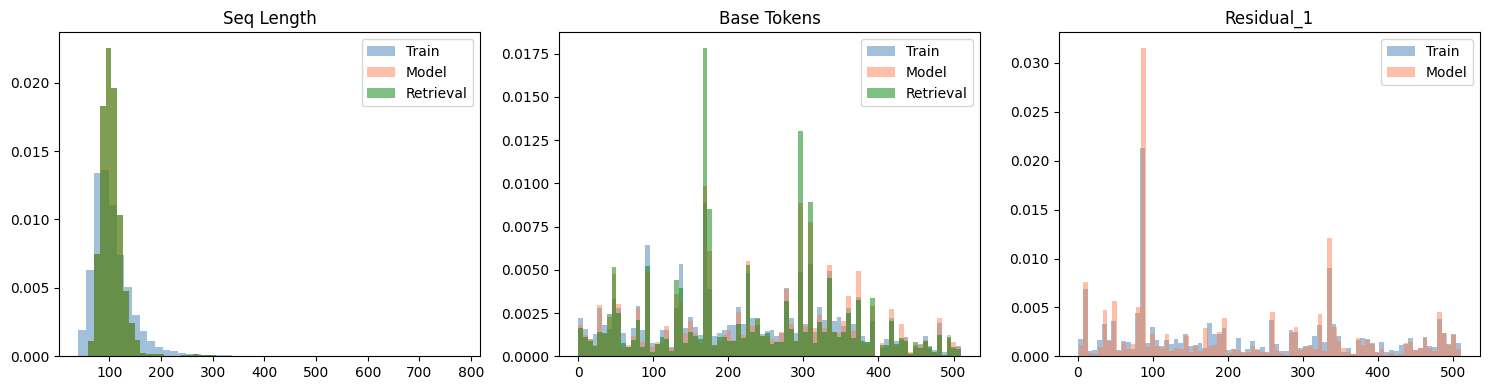

In [20]:
sl_m = sub['base_tokens'].apply(lambda x: len(str(x).split()))
sl_r = ret_sub['base_tokens'].apply(lambda x: len(str(x).split()))
fig, axes = plt.subplots(1,3,figsize=(15,4))
ax = axes[0]
ax.hist(train_valid['seq_len'],bins=50,alpha=.5,label='Train',density=True,color='steelblue')
ax.hist(sl_m,bins=50,alpha=.5,label='Model',density=True,color='coral')
ax.hist(sl_r,bins=50,alpha=.5,label='Retrieval',density=True,color='green')
ax.set_title('Seq Length'); ax.legend()
ax = axes[1]
tbf=[]; mbf=[]; rbf=[]
for _,r in train_valid.head(500).iterrows(): tbf.extend(parse_tokens(r['base_tokens'])[:80])
for _,r in sub.head(500).iterrows(): mbf.extend(list(map(int,str(r['base_tokens']).split()[:80])))
for _,r in ret_sub.head(500).iterrows(): rbf.extend(list(map(int,str(r['base_tokens']).split()[:80])))
ax.hist(tbf,bins=80,alpha=.5,label='Train',density=True,color='steelblue')
ax.hist(mbf,bins=80,alpha=.5,label='Model',density=True,color='coral')
ax.hist(rbf,bins=80,alpha=.5,label='Retrieval',density=True,color='green')
ax.set_title('Base Tokens'); ax.legend()
ax = axes[2]
trf=[]; mrf=[]
for _,r in train_valid.head(500).iterrows(): trf.extend(parse_tokens(r['residual_1'])[:80])
for _,r in sub.head(500).iterrows(): mrf.extend(list(map(int,str(r['residual_1']).split()[:80])))
ax.hist(trf,bins=80,alpha=.5,label='Train',density=True,color='steelblue')
ax.hist(mrf,bins=80,alpha=.5,label='Model',density=True,color='coral')
ax.set_title('Residual_1'); ax.legend()
plt.tight_layout(); plt.show()

In [21]:
print('='*60)
print('SUMMARY v6')
print(f'  Total time: {(time.time()-T_START)/60:.1f} min')
print(f'  Time left: {time_left()/60:.0f} min')
print(f'  Refiner loss: {best_loss:.4f}')
print(f'  Predictions: {len(all_preds)}')
print(f'  Retrieval K: {CFG.ret_k}')
print(f'  Temperatures: {CFG.temperatures}')
print(f'  Candidates: {len(CFG.temperatures)*CFG.n_cand_per_t} per sample')
print(f'  submission.csv = model-refined')
print(f'  submission_retrieval.csv = pure voting')
print('  Try BOTH and compare scores!')
print('='*60)

SUMMARY v6
  Total time: 76.0 min
  Time left: 434 min
  Refiner loss: 4.0842
  Predictions: 3000
  Retrieval K: 20
  Temperatures: [0.6, 0.7, 0.8]
  Candidates: 6 per sample
  submission.csv = model-refined
  submission_retrieval.csv = pure voting
  Try BOTH and compare scores!
